# Assignment 1 — Exploratory Data Analysis (EDA)
## Food Delivery Operations Dataset

**Course:** Introduction to Data Science  
**Student name:** DAVID OFRI  
**Student ID:** 208151324  


### Goal
This notebook performs a complete exploratory data analysis of a food-delivery dataset, from raw-file inspection through data-quality checks, univariate analysis, relationships, visualizations, index/time analysis, conclusions, and bonus analyses.

The analysis intentionally distinguishes between:
- facts directly observed in the CSV,
- reasonable operational interpretations,
- assumptions that should **not** be treated as verified facts.

## 1. Dataset Selection and Source

### Dataset choice
The dataset contains operational food-delivery records. It is suitable for this assignment because it is tabular, has far more than 1,000 rows, contains 20 original columns, and combines numerical, categorical, date, and time variables.

### Source
The file corresponds to the Kaggle dataset commonly distributed under the slug:

`gauravmalik26/food-delivery-dataset`

Dataset page: `https://www.kaggle.com/datasets/gauravmalik26/food-delivery-dataset`

### Collection purpose and collector
The table structure and the target field `Time_taken(min)` indicate that the data is intended for analyzing or predicting food-delivery duration from operational variables such as traffic, weather, courier characteristics, vehicle type, festival status, and location.

The CSV itself does **not** document the original organization that collected the records. Therefore, the Kaggle uploader should not automatically be treated as the primary collector. This missing provenance is itself an important limitation.

In [1]:
# If one of these imports fails on a new computer, run this once:
# %pip install pandas numpy matplotlib scipy

from pathlib import Path
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

In [2]:
# The CSV should be in the same folder as this notebook.
DATA_PATH = Path("train.csv")

# This fallback allows the notebook to run in the environment where it was prepared.
if not DATA_PATH.exists() and Path("/mnt/data/train.csv").exists():
    DATA_PATH = Path("/mnt/data/train.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "train.csv was not found. Place train.csv in the same folder as this notebook."
    )

df_raw = pd.read_csv(DATA_PATH)

print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df_raw.shape}")
display(df_raw.head())

Loaded: train.csv
Shape: (45593, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745,75.892,22.765,75.912,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913,77.683,13.043,77.813,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914,77.678,12.924,77.688,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.004,76.976,11.054,77.026,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.973,80.250,13.013,80.290,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


### Initial observation
The dataset contains **45,593 rows and 20 original columns**, so it comfortably satisfies the assignment's size requirements. The first rows show a mix of courier attributes, coordinates, date/time fields, weather, traffic, vehicle information, city type, and delivery duration.

# 2. Meta-Analysis of the File
## 2.1 File Analysis

In [3]:
file_size_bytes = os.path.getsize(DATA_PATH)
file_size_mb = file_size_bytes / (1024 ** 2)

print(f"File name: {DATA_PATH.name}")
print(f"File format: {DATA_PATH.suffix.lower()}")
print(f"File size on disk: {file_size_mb:.2f} MB")
print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")

print("\nImportant note about creation date:")
print(
    "The CSV does not contain authoritative original file-creation metadata. "
    "A local filesystem timestamp would describe this copy, not necessarily "
    "the creation date of the source dataset."
)

File name: train.csv
File format: .csv
File size on disk: 7.41 MB
Rows: 45,593
Columns: 20

Important note about creation date:
The CSV does not contain authoritative original file-creation metadata. A local filesystem timestamp would describe this copy, not necessarily the creation date of the source dataset.


### Observation
The file is a flat CSV of roughly **7.4 MB on disk**. A CSV does not preserve rich source metadata, so the original creation date cannot be verified from the file alone. Reporting the computer's local creation timestamp as the dataset's original creation date would be misleading.

## 2.2 Data Structure

In [4]:
print("Column names:")
for column in df_raw.columns:
    print(f"- {column}")

print("\nRaw data types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nIndex:")
print(f"Index type: {type(df_raw.index).__name__}")
print(f"Index unique: {df_raw.index.is_unique}")
print(f"ID column unique: {df_raw['ID'].is_unique}")

Column names:
- ID
- Delivery_person_ID
- Delivery_person_Age
- Delivery_person_Ratings
- Restaurant_latitude
- Restaurant_longitude
- Delivery_location_latitude
- Delivery_location_longitude
- Order_Date
- Time_Orderd
- Time_Order_picked
- Weatherconditions
- Road_traffic_density
- Vehicle_condition
- Type_of_order
- Type_of_vehicle
- multiple_deliveries
- Festival
- City
- Time_taken(min)

Raw data types:


,dtype
ID,str
Delivery_person_ID,str
Delivery_person_Age,str
Delivery_person_Ratings,str
Restaurant_latitude,float64
Restaurant_longitude,float64
Delivery_location_latitude,float64
Delivery_location_longitude,float64
Order_Date,str
Time_Orderd,str



Index:
Index type: RangeIndex
Index unique: True
ID column unique: True


### Structure observation
Several columns that conceptually represent numbers or time are initially stored as `object`, including courier age, courier rating, order time, pickup time, multiple deliveries, and delivery time. This matters because arithmetic, correlations, and time-based analysis require explicit conversion.

The default Pandas index is unique but purely technical. The `ID` column is also unique and is a stronger business identifier for an order.

# 3. Data Cleaning for Analysis

Cleaning is performed on a copy so the raw data remains unchanged. The main operations are:
1. trim whitespace from text fields,
2. convert textual missing markers to real `NaN`,
3. remove the `conditions ` prefix from weather labels,
4. convert numeric-looking columns to numeric types,
5. parse date/time fields,
6. extract the numerical delivery time from strings such as `(min) 24`,
7. engineer preparation time and delivery distance for later analysis.

In [5]:
df = df_raw.copy()

# Standardize object columns: trim whitespace and convert textual missing markers.
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].astype(str).str.strip()
    df[column] = df[column].replace(
        {"NaN": np.nan, "nan": np.nan, "None": np.nan, "": np.nan}
    )

# Weather strings contain a redundant prefix such as "conditions Sunny".
df["Weatherconditions"] = df["Weatherconditions"].str.replace(
    r"^conditions\s+", "", regex=True
)
df["Weatherconditions"] = df["Weatherconditions"].replace(
    {"NaN": np.nan, "nan": np.nan}
)

# Convert numeric-looking columns.
for column in [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Extract the numerical part of delivery time.
df["Time_taken_min"] = pd.to_numeric(
    df["Time_taken(min)"].astype("string").str.extract(r"(\d+(?:\.\d+)?)")[0],
    errors="coerce",
)

# Parse date and time.
df["Order_Date_parsed"] = pd.to_datetime(
    df["Order_Date"], format="%d-%m-%Y", errors="coerce"
)
df["Time_Orderd_parsed"] = pd.to_datetime(
    df["Time_Orderd"], format="%H:%M:%S", errors="coerce"
)
df["Time_Order_picked_parsed"] = pd.to_datetime(
    df["Time_Order_picked"], format="%H:%M:%S", errors="coerce"
)

# Preparation time in minutes.
order_minutes = (
    df["Time_Orderd_parsed"].dt.hour * 60
    + df["Time_Orderd_parsed"].dt.minute
    + df["Time_Orderd_parsed"].dt.second / 60
)
pickup_minutes = (
    df["Time_Order_picked_parsed"].dt.hour * 60
    + df["Time_Order_picked_parsed"].dt.minute
    + df["Time_Order_picked_parsed"].dt.second / 60
)
preparation_minutes = pickup_minutes - order_minutes
preparation_minutes = np.where(
    preparation_minutes < 0, preparation_minutes + 24 * 60, preparation_minutes
)
df["Preparation_time_min"] = preparation_minutes

# Time-derived features.
df["Order_hour"] = df["Time_Orderd_parsed"].dt.hour
df["Day_of_week"] = df["Order_Date_parsed"].dt.day_name()

# Haversine distance.
def haversine_km(lat1, lon1, lat2, lon2):
    earth_radius_km = 6371.0
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)
    delta_lat = np.radians(lat2 - lat1)
    delta_lon = np.radians(lon2 - lon1)

    a = (
        np.sin(delta_lat / 2) ** 2
        + np.cos(lat1_rad)
        * np.cos(lat2_rad)
        * np.sin(delta_lon / 2) ** 2
    )
    return 2 * earth_radius_km * np.arcsin(np.sqrt(a))

df["Distance_km_raw"] = haversine_km(
    df["Restaurant_latitude"],
    df["Restaurant_longitude"],
    df["Delivery_location_latitude"],
    df["Delivery_location_longitude"],
)

print("Cleaning complete.")
display(
    df[
        [
            "Delivery_person_Age",
            "Delivery_person_Ratings",
            "Order_Date_parsed",
            "Time_Orderd_parsed",
            "Weatherconditions",
            "Time_taken_min",
            "Preparation_time_min",
            "Distance_km_raw",
        ]
    ].head()
)

C:\Users\david\AppData\Local\Temp\ipykernel_21392\2198323016.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include="object").columns:


Cleaning complete.


,Delivery_person_Age,Delivery_person_Ratings,Order_Date_parsed,Time_Orderd_parsed,Weatherconditions,Time_taken_min,Preparation_time_min,Distance_km_raw
0,37.000,4.900,2022-03-19,1900-01-01 11:30:00,Sunny,24,15.000,3.025
1,34.000,4.500,2022-03-25,1900-01-01 19:45:00,Stormy,33,5.000,20.184
2,23.000,4.400,2022-03-19,1900-01-01 08:30:00,Sandstorms,26,15.000,1.553
3,38.000,4.700,2022-04-05,1900-01-01 18:00:00,Sunny,21,10.000,7.790
4,32.000,4.600,2022-03-26,1900-01-01 13:30:00,Cloudy,30,15.000,6.210


# 4. Data Quality and Completeness
## 4.1 Missing Data

,Missing Values,Percentage (%)
Delivery_person_Ratings,1908,4.185
Delivery_person_Age,1854,4.066
Time_Orderd,1731,3.797
Preparation_time_min,1731,3.797
Order_hour,1731,3.797
Time_Orderd_parsed,1731,3.797
City,1200,2.632
multiple_deliveries,993,2.178
Weatherconditions,616,1.351
Road_traffic_density,601,1.318



Rows where both weather and traffic are missing: 601
Total weather missing: 616
Total traffic missing: 601


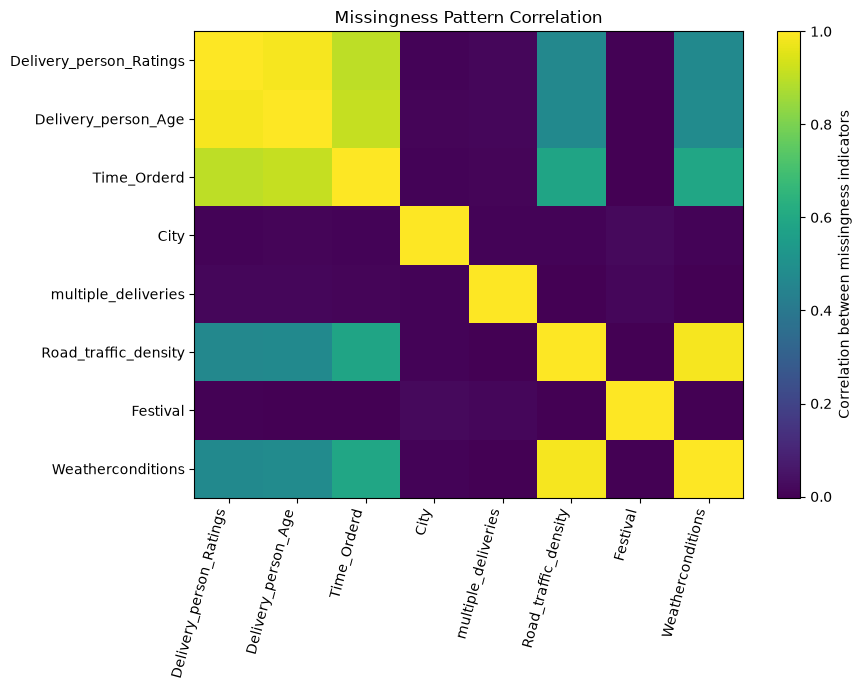

In [6]:
missing_summary = pd.DataFrame(
    {
        "Missing Values": df.isna().sum(),
        "Percentage (%)": df.isna().mean() * 100,
    }
)

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values("Percentage (%)", ascending=False)

display(missing_summary)

# Examine whether missingness is independent or shared between fields.
missing_columns = [
    column
    for column in [
        "Delivery_person_Ratings",
        "Delivery_person_Age",
        "Time_Orderd",
        "City",
        "multiple_deliveries",
        "Road_traffic_density",
        "Festival",
        "Weatherconditions",
    ]
    if column in df.columns
]

missing_indicators = pd.DataFrame(
    {column: df[column].isna().astype(int) for column in missing_columns}
)
missing_corr = missing_indicators.corr()

print(
    "\nRows where both weather and traffic are missing:",
    int(
        (
            df["Weatherconditions"].isna()
            & df["Road_traffic_density"].isna()
        ).sum()
    ),
)
print("Total weather missing:", int(df["Weatherconditions"].isna().sum()))
print("Total traffic missing:", int(df["Road_traffic_density"].isna().sum()))

plt.figure(figsize=(9, 7))
plt.imshow(missing_corr.values, aspect="auto")
plt.colorbar(label="Correlation between missingness indicators")
plt.xticks(range(len(missing_corr.columns)), missing_corr.columns, rotation=75, ha="right")
plt.yticks(range(len(missing_corr.index)), missing_corr.index)
plt.title("Missingness Pattern Correlation")
plt.tight_layout()
plt.show()

### Missing-data observation
Missingness is **not fully random**. Courier age and rating are missing together in many rows, and almost every missing traffic value is accompanied by a missing weather value. Specifically, traffic has 601 missing values and all 601 occur in rows where weather is also missing.

This shared pattern suggests a structured data-generation or data-ingestion issue rather than independent random missingness. Therefore, blindly filling every missing value with a mean or mode could erase useful information.

### Suggested treatment
- **Courier age / rating:** median imputation may be reasonable for a simple model, but a missing-indicator feature should also be considered because the missingness is structured.
- **Weather / traffic:** preserve an `Unknown` category or model missingness explicitly rather than silently replacing it with the mode.
- **City / festival / multiple deliveries:** mode imputation can be considered if a model requires complete data, but the imputation decision should be documented.
- For EDA, it is preferable to keep missing values visible whenever possible.

## 4.2 Duplicates

In [7]:
full_duplicates = int(df_raw.duplicated().sum())
id_duplicates = int(df_raw.duplicated(subset=["ID"]).sum())

print(f"Full duplicate rows: {full_duplicates}")
print(f"Duplicate order IDs: {id_duplicates}")

Full duplicate rows: 0
Duplicate order IDs: 0


### Duplicate observation
There are **no full duplicate rows** and **no duplicated order IDs**. Therefore, dropping duplicates is unnecessary for this version of the dataset.

If duplicates existed, full duplicates could usually be removed after validation. Partial duplicates would require more care because repeated IDs with different timestamps or statuses could represent updates rather than accidental duplication.

## 4.3 Suspicious and Impossible Values

In [8]:
suspicious_summary = {
    "Courier age < 18": int((df["Delivery_person_Age"] < 18).sum()),
    "Courier age > 65": int((df["Delivery_person_Age"] > 65).sum()),
    "Rating < 1": int((df["Delivery_person_Ratings"] < 1).sum()),
    "Rating > 5": int((df["Delivery_person_Ratings"] > 5).sum()),
    "Restaurant latitude or longitude = 0": int(
        (
            (df["Restaurant_latitude"] == 0)
            | (df["Restaurant_longitude"] == 0)
        ).sum()
    ),
    "Negative restaurant latitude": int((df["Restaurant_latitude"] < 0).sum()),
    "Negative restaurant longitude": int((df["Restaurant_longitude"] < 0).sum()),
    "Non-positive delivery time": int((df["Time_taken_min"] <= 0).sum()),
    "Raw distance > 100 km": int((df["Distance_km_raw"] > 100).sum()),
}

display(pd.Series(suspicious_summary, name="Count").to_frame())

print("\nSelected numeric bounds:")
display(
    df[
        [
            "Delivery_person_Age",
            "Delivery_person_Ratings",
            "Time_taken_min",
            "Distance_km_raw",
        ]
    ].describe().loc[["min", "max"]]
)

,Count
Courier age < 18,38
Courier age > 65,0
Rating < 1,0
Rating > 5,53
Restaurant latitude or longitude = 0,3640
Negative restaurant latitude,431
Negative restaurant longitude,162
Non-positive delivery time,0
Raw distance > 100 km,431



Selected numeric bounds:


,Delivery_person_Age,Delivery_person_Ratings,Time_taken_min,Distance_km_raw
min,15.000,1.000,10.000,1.465
max,50.000,6.000,54.000,"19,692.675"


### Suspicious-value observation
Several values require caution:
- **38 courier-age records are below 18**, with a minimum of 15.
- **53 ratings exceed 5**, even though a five-star scale would normally stop at 5.
- **3,640 rows have a zero restaurant coordinate**.
- Hundreds of restaurant coordinates contain negative signs that produce implausibly large delivery distances when paired with the destination coordinates.
- **431 raw Haversine distances exceed 100 km**, while the 99th percentile of the non-extreme distribution is only around 21 km.

These are strong signs of placeholder values, sign errors, or malformed coordinates. The original `Time_taken(min)` field also includes a textual unit prefix `(min)`, which is not a missing value but is a formatting obstacle that must be cleaned before statistical analysis.

For model building, suspicious records should be investigated or flagged instead of automatically trusted.

## 4.4 Cardinality

In [9]:
cardinality = df.nunique(dropna=True).sort_values(ascending=False)

print("Columns with one unique non-missing value:")
single_value_columns = cardinality[cardinality == 1]
display(single_value_columns.to_frame("Unique Values"))

print("\nHighest-cardinality columns:")
display(cardinality.head(12).to_frame("Unique Values"))

Columns with one unique non-missing value:


,Unique Values



Highest-cardinality columns:


,Unique Values
ID,45593
Distance_km_raw,4791
Delivery_location_latitude,4373
Delivery_location_longitude,4373
Delivery_person_ID,1320
Restaurant_latitude,657
Restaurant_longitude,518
Time_Order_picked,193
Time_Order_picked_parsed,193
Time_Orderd_parsed,176


### Cardinality observation
There are no constant columns. `ID` has one unique value per record and is therefore an identifier rather than a predictive category. `Delivery_person_ID` also has high cardinality (1,320 unique couriers).

Direct one-hot encoding of identifiers can create thousands of sparse columns and encourage overfitting. `ID` should normally be excluded from predictive features, while courier-level history should be summarized into meaningful features rather than encoded as a raw label.

# 5. Univariate Analysis
## 5.1 Numerical Variable — Delivery Time

In [10]:
delivery_time = df["Time_taken_min"].dropna()

mean_value = delivery_time.mean()
median_value = delivery_time.median()
std_value = delivery_time.std()
mean_abs_deviation = (delivery_time - mean_value).abs().mean()
median_abs_deviation = stats.median_abs_deviation(
    delivery_time, scale=1, nan_policy="omit"
)
minimum = delivery_time.min()
maximum = delivery_time.max()
q1 = delivery_time.quantile(0.25)
q3 = delivery_time.quantile(0.75)
iqr = q3 - q1
skewness = delivery_time.skew()

summary_stats = pd.Series(
    {
        "Mean": mean_value,
        "Median": median_value,
        "Std Dev": std_value,
        "Mean Absolute Deviation": mean_abs_deviation,
        "Median Absolute Deviation": median_abs_deviation,
        "Min": minimum,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Max": maximum,
        "Skewness": skewness,
    }
)
display(summary_stats.to_frame("Value"))

# Three one-dimensional outlier methods.
z_scores = np.abs(stats.zscore(delivery_time))
z_outliers = int((z_scores > 3).sum())

lower_iqr = q1 - 1.5 * iqr
upper_iqr = q3 + 1.5 * iqr
iqr_outliers = int(
    ((delivery_time < lower_iqr) | (delivery_time > upper_iqr)).sum()
)

p01 = delivery_time.quantile(0.01)
p99 = delivery_time.quantile(0.99)
percentile_outliers = int(
    ((delivery_time < p01) | (delivery_time > p99)).sum()
)

outlier_table = pd.DataFrame(
    {
        "Method": ["Z-score > 3", "IQR rule", "Outside 1st–99th percentiles"],
        "Outlier Count": [z_outliers, iqr_outliers, percentile_outliers],
    }
)
display(outlier_table)

,Value
Mean,26.295
Median,26.000
Std Dev,9.384
Mean Absolute Deviation,7.594
Median Absolute Deviation,7.000
Min,10.000
Q1,19.000
Q3,32.000
IQR,13.000
Max,54.000


,Method,Outlier Count
0,Z-score > 3,0
1,IQR rule,270
2,Outside 1st–99th percentiles,436


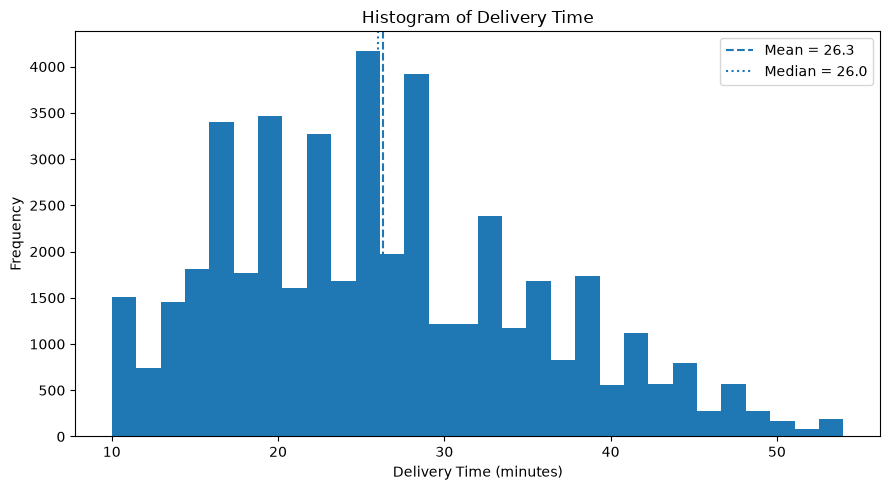

In [11]:
plt.figure(figsize=(9, 5))
plt.hist(delivery_time, bins=30)
plt.axvline(mean_value, linestyle="--", label=f"Mean = {mean_value:.1f}")
plt.axvline(median_value, linestyle=":", label=f"Median = {median_value:.1f}")
plt.title("Histogram of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Numerical-variable observation
Delivery time has a mean of about **26.29 minutes** and a median of **26 minutes**. The skewness is approximately **0.49**, indicating moderate right skew: slower deliveries create a longer right tail.

The three outlier methods disagree:
- Z-score > 3 finds no outliers,
- the IQR rule identifies about 270 observations,
- the 1st–99th percentile rule flags about 436 observations.

This disagreement is expected because each method uses a different definition of "unusual." The IQR method is more robust than a Z-score rule when the distribution is not perfectly normal.

## 5.2 Categorical Variable — Weather

In [12]:
weather_counts = df["Weatherconditions"].value_counts(dropna=True)
weather_percent = df["Weatherconditions"].value_counts(
    normalize=True, dropna=True
) * 100

mode_value = weather_counts.index[0]
mode_percent = weather_percent.iloc[0]

K = 3
top_k = weather_percent.head(K)
top_k_coverage = top_k.sum()

P = 80.0
cumulative_weather = weather_percent.cumsum()
minimum_categories_for_p = int((cumulative_weather < P).sum() + 1)
categories_for_p = list(
    cumulative_weather.head(minimum_categories_for_p).index
)

rare_threshold = 5.0
rare_weather = weather_percent[weather_percent < rare_threshold]

print(f"Mode: {mode_value} ({mode_percent:.2f}%)")
print(f"Top {K} categories cover: {top_k_coverage:.2f}%")
print(
    f"Minimum number of categories required to cover {P:.0f}%: "
    f"{minimum_categories_for_p}"
)
print("Categories:", categories_for_p)

print("\nRare weather categories (<5%):")
display(rare_weather.to_frame("Percentage (%)"))

Mode: Fog (17.02%)
Top 3 categories cover: 50.64%
Minimum number of categories required to cover 80%: 5
Categories: ['Fog', 'Stormy', 'Cloudy', 'Sandstorms', 'Windy']

Rare weather categories (<5%):


,Percentage (%)
Weatherconditions,


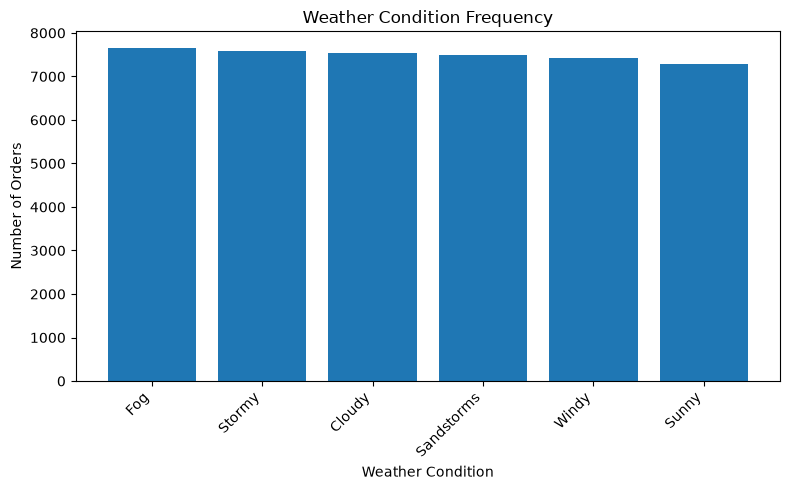

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(weather_counts.index, weather_counts.values)
plt.title("Weather Condition Frequency")
plt.xlabel("Weather Condition")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

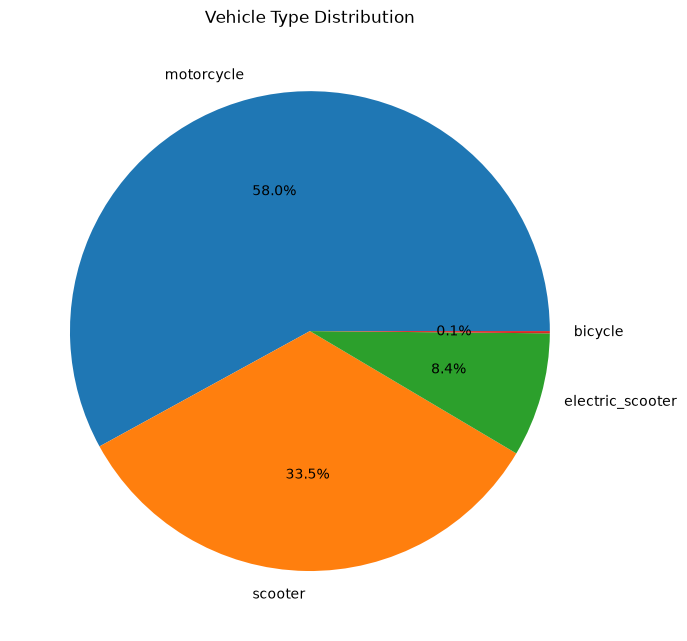

In [14]:
vehicle_counts = df["Type_of_vehicle"].value_counts(dropna=True)

plt.figure(figsize=(7, 7))
plt.pie(vehicle_counts.values, labels=vehicle_counts.index, autopct="%1.1f%%")
plt.title("Vehicle Type Distribution")
plt.tight_layout()
plt.show()

### Categorical-variable observation
Weather is distributed quite evenly across the six observed conditions. The most common category is fog, but it accounts for only about **17%** of non-missing weather records. The top three weather categories together cover only about **51%**, and five categories are required to cover at least 80%.

Therefore, the mode is **not** an adequate summary of weather. No genuine weather category is rare under a 5% threshold.

Other categorical fields do contain rare categories. For example, bicycles and semi-urban deliveries are uncommon, so merging or dropping rare labels would require domain justification rather than an automatic rule.

# 6. Correlations and Relationships
## 6.1 Numerical–Numerical Relationships

In [15]:
numeric_relationship_columns = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Vehicle_condition",
    "multiple_deliveries",
    "Preparation_time_min",
    "Time_taken_min",
]

correlation_data = df[numeric_relationship_columns].dropna()

pearson_corr = correlation_data.corr(method="pearson")
spearman_corr = correlation_data.corr(method="spearman")
kendall_corr = correlation_data.corr(method="kendall")

print("Pearson correlation:")
display(pearson_corr.round(3))

print("\nSpearman correlation:")
display(spearman_corr.round(3))

print("\nKendall correlation:")
display(kendall_corr.round(3))

Pearson correlation:


,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,Preparation_time_min,Time_taken_min
Delivery_person_Age,1.000,-0.117,-0.002,0.118,-0.008,0.303
Delivery_person_Ratings,-0.117,1.000,0.048,-0.127,0.006,-0.361
Vehicle_condition,-0.002,0.048,1.000,-0.103,0.007,-0.244
multiple_deliveries,0.118,-0.127,-0.103,1.000,-0.005,0.388
Preparation_time_min,-0.008,0.006,0.007,-0.005,1.000,-0.009
Time_taken_min,0.303,-0.361,-0.244,0.388,-0.009,1.000



Spearman correlation:


,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,Preparation_time_min,Time_taken_min
Delivery_person_Age,1.000,-0.103,-0.002,0.112,-0.008,0.312
Delivery_person_Ratings,-0.103,1.000,0.067,-0.092,0.003,-0.296
Vehicle_condition,-0.002,0.067,1.000,-0.090,0.007,-0.227
multiple_deliveries,0.112,-0.092,-0.090,1.000,-0.004,0.341
Preparation_time_min,-0.008,0.003,0.007,-0.004,1.000,-0.008
Time_taken_min,0.312,-0.296,-0.227,0.341,-0.008,1.000



Kendall correlation:


,Delivery_person_Age,Delivery_person_Ratings,Vehicle_condition,multiple_deliveries,Preparation_time_min,Time_taken_min
Delivery_person_Age,1.000,-0.075,-0.001,0.092,-0.006,0.216
Delivery_person_Ratings,-0.075,1.000,0.055,-0.078,0.002,-0.213
Vehicle_condition,-0.001,0.055,1.000,-0.083,0.006,-0.177
multiple_deliveries,0.092,-0.078,-0.083,1.000,-0.004,0.284
Preparation_time_min,-0.006,0.002,0.006,-0.004,1.000,-0.006
Time_taken_min,0.216,-0.213,-0.177,0.284,-0.006,1.000


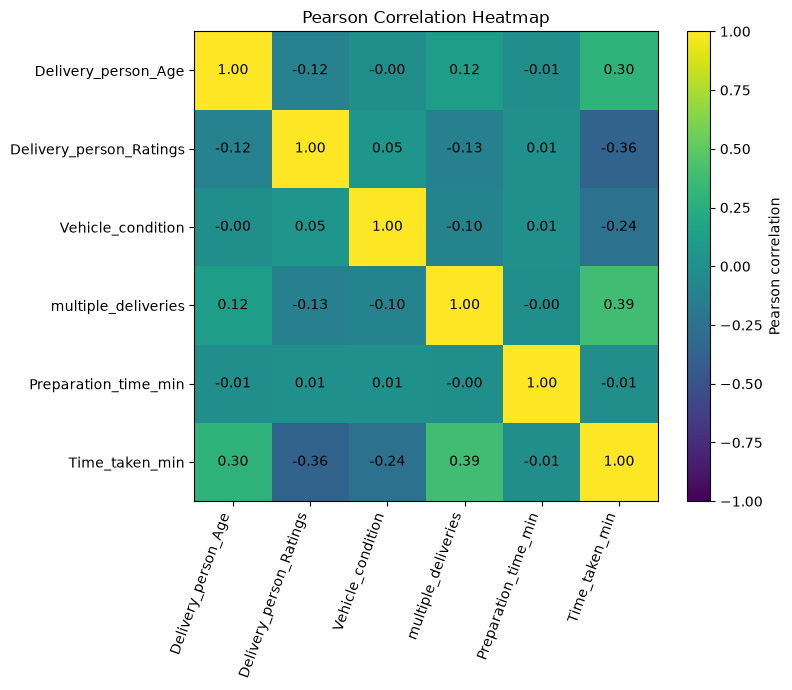

In [16]:
plt.figure(figsize=(8, 7))
plt.imshow(pearson_corr.values, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(
    range(len(pearson_corr.columns)),
    pearson_corr.columns,
    rotation=70,
    ha="right",
)
plt.yticks(range(len(pearson_corr.index)), pearson_corr.index)

for row in range(len(pearson_corr.index)):
    for col in range(len(pearson_corr.columns)):
        plt.text(
            col,
            row,
            f"{pearson_corr.iloc[row, col]:.2f}",
            ha="center",
            va="center",
        )

plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

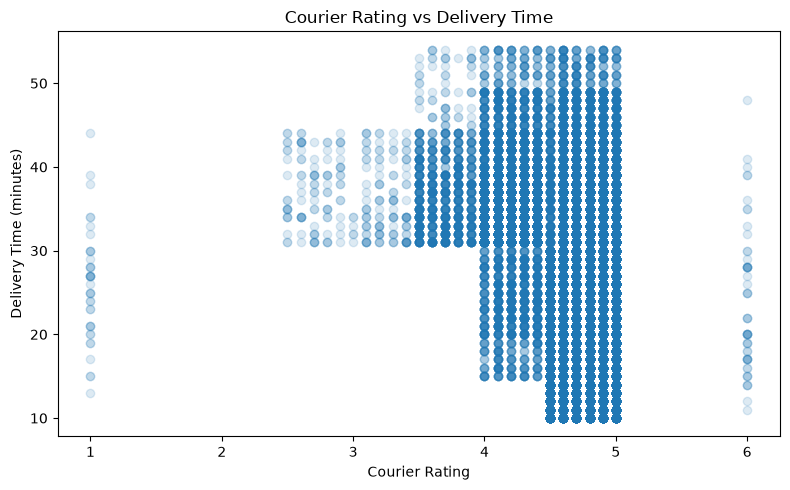

In [17]:
scatter_sample = df[
    ["Delivery_person_Ratings", "Time_taken_min"]
].dropna()

plt.figure(figsize=(8, 5))
plt.scatter(
    scatter_sample["Delivery_person_Ratings"],
    scatter_sample["Time_taken_min"],
    alpha=0.15,
)
plt.title("Courier Rating vs Delivery Time")
plt.xlabel("Courier Rating")
plt.ylabel("Delivery Time (minutes)")
plt.tight_layout()
plt.show()

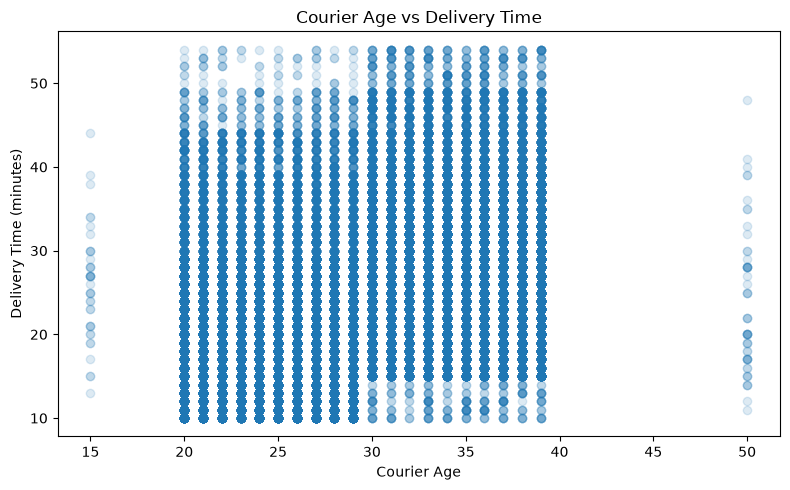

In [18]:
age_sample = df[
    ["Delivery_person_Age", "Time_taken_min"]
].dropna()

plt.figure(figsize=(8, 5))
plt.scatter(
    age_sample["Delivery_person_Age"],
    age_sample["Time_taken_min"],
    alpha=0.15,
)
plt.title("Courier Age vs Delivery Time")
plt.xlabel("Courier Age")
plt.ylabel("Delivery Time (minutes)")
plt.tight_layout()
plt.show()

### Pearson, Spearman, and Kendall — difference and interpretation
- **Pearson** measures linear association and is more sensitive to extreme values.
- **Spearman** converts values to ranks and measures monotonic association, so it is more robust to non-linearity and outliers.
- **Kendall** is also rank-based and evaluates concordant/discordant pairs; it is often useful when many tied ranks exist.

The three methods tell a consistent directional story:
- courier age is positively associated with delivery time,
- courier rating is negatively associated with delivery time,
- multiple deliveries are positively associated with delivery time,
- better vehicle condition is negatively associated with delivery time,
- preparation time has almost no linear relationship with final delivery duration in this file.

These are **associations**, not causal conclusions. For example, rating and delivery time may influence each other, and both may also depend on traffic, route, city, and workload.

## 6.2 Categorical–Categorical Relationship
### Weather vs Road Traffic Density

In [19]:
weather_traffic_table = pd.crosstab(
    df["Weatherconditions"],
    df["Road_traffic_density"],
)
display(weather_traffic_table)

def cramers_v(contingency_table):
    chi2, p_value, _, _ = stats.chi2_contingency(contingency_table)
    n = contingency_table.to_numpy().sum()
    rows, columns = contingency_table.shape
    denominator = min(rows - 1, columns - 1)
    value = math.sqrt((chi2 / n) / denominator)
    return value, chi2, p_value

weather_traffic_v, weather_traffic_chi2, weather_traffic_p = cramers_v(
    weather_traffic_table
)

print(f"Cramer's V: {weather_traffic_v:.4f}")
print(f"Chi-square statistic: {weather_traffic_chi2:.3f}")
print(f"p-value: {weather_traffic_p:.6f}")

Road_traffic_density,High,Jam,Low,Medium
Weatherconditions,,,,
Cloudy,744,2349,2605,1838
Fog,776,2429,2597,1852
Sandstorms,701,2399,2609,1786
Stormy,733,2323,2699,1831
Sunny,735,2289,2475,1785
Windy,735,2351,2484,1852


Cramer's V: 0.0104
Chi-square statistic: 14.613
p-value: 0.479639


### Categorical–categorical observation
After converting textual `NaN` markers into **real missing values** and excluding them from the contingency table, Cramér's V is about **0.01**, indicating almost no association between the observed weather category and road-traffic category.

This section exposes an important data-quality trap: if the string `"NaN"` is incorrectly treated as an ordinary category, the shared missingness between weather and traffic creates an artificially strong relationship. Correct missing-value handling changes the conclusion dramatically.

## 6.3 Categorical–Numerical Relationship with Binning
### Road Traffic vs Delivery Time

In [20]:
df["Delivery_time_bin"] = pd.qcut(
    df["Time_taken_min"],
    q=3,
    labels=["Fast", "Typical", "Slow"],
)

traffic_by_time_bin = pd.crosstab(
    df["Road_traffic_density"],
    df["Delivery_time_bin"],
    normalize="index",
) * 100

traffic_delivery_summary = (
    df.groupby("Road_traffic_density", observed=True)["Time_taken_min"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean")
)

print("Delivery-time bins by traffic level (% within traffic level):")
display(traffic_by_time_bin.round(2))

print("\nDelivery-time summary by traffic level:")
display(traffic_delivery_summary.round(2))

Delivery-time bins by traffic level (% within traffic level):


Delivery_time_bin,Fast,Typical,Slow
Road_traffic_density,,,
High,24.560,37.630,37.810
Jam,18.450,27.430,54.120
Low,55.090,36.240,8.660
Medium,30.250,33.660,36.090



Delivery-time summary by traffic level:


,count,mean,median,std
Road_traffic_density,,,,
Low,15477,21.270,20.000,6.800
Medium,10947,26.700,27.000,8.560
High,4425,27.240,27.000,8.400
Jam,14143,31.180,31.000,9.940


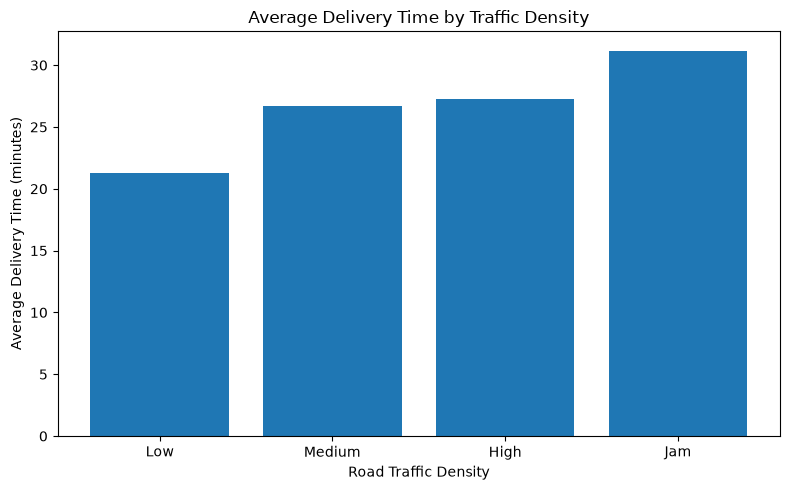

In [21]:
traffic_means = traffic_delivery_summary["mean"]

plt.figure(figsize=(8, 5))
plt.bar(traffic_means.index, traffic_means.values)
plt.title("Average Delivery Time by Traffic Density")
plt.xlabel("Road Traffic Density")
plt.ylabel("Average Delivery Time (minutes)")
plt.tight_layout()
plt.show()

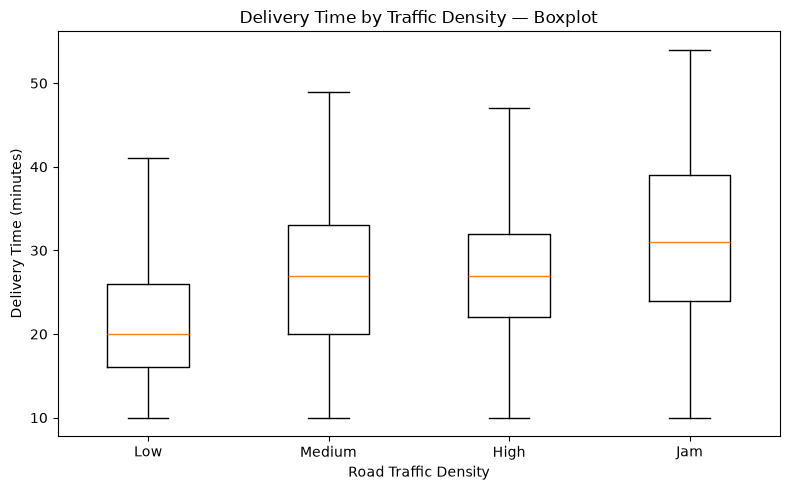

In [22]:
traffic_levels = [
    level
    for level in ["Low", "Medium", "High", "Jam"]
    if level in set(df["Road_traffic_density"].dropna())
]
traffic_box_data = [
    df.loc[
        df["Road_traffic_density"] == level,
        "Time_taken_min",
    ].dropna()
    for level in traffic_levels
]

plt.figure(figsize=(8, 5))
plt.boxplot(traffic_box_data, tick_labels=traffic_levels, showfliers=False)
plt.title("Delivery Time by Traffic Density — Boxplot")
plt.xlabel("Road Traffic Density")
plt.ylabel("Delivery Time (minutes)")
plt.tight_layout()
plt.show()

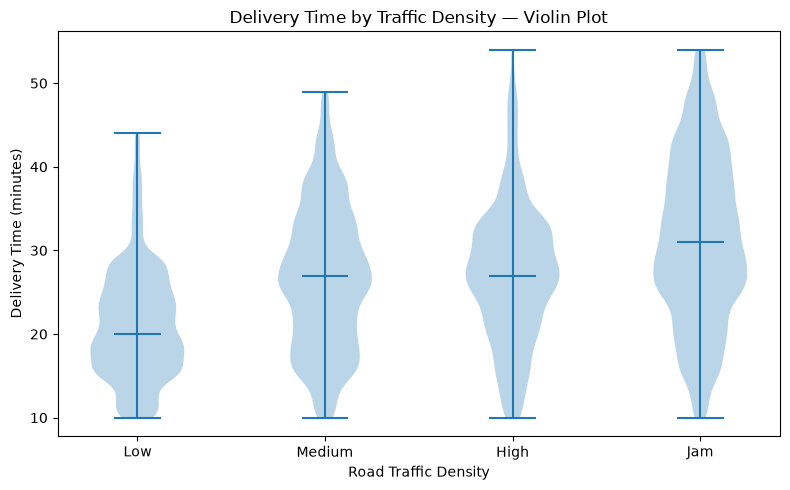

In [23]:
plt.figure(figsize=(8, 5))
plt.violinplot(
    traffic_box_data,
    positions=np.arange(1, len(traffic_levels) + 1),
    showmedians=True,
)
plt.xticks(np.arange(1, len(traffic_levels) + 1), traffic_levels)
plt.title("Delivery Time by Traffic Density — Violin Plot")
plt.xlabel("Road Traffic Density")
plt.ylabel("Delivery Time (minutes)")
plt.tight_layout()
plt.show()

### Traffic observation
Traffic density is strongly informative. Average delivery time is lowest under **Low** traffic (about 21 minutes) and highest under **Jam** traffic (about 31 minutes). More than half of the jam-traffic observations fall into the slowest delivery-time third.

The boxplot and violin plot show that the difference is not just a small shift in the mean; the overall delivery-time distributions move as traffic becomes heavier.

## 6.4 Pairwise Numerical Relationships

A traditional pairplot is a grid of many subplots. To keep each visualization readable, the same pairwise idea is implemented below as separate scatter figures for the three key variables.

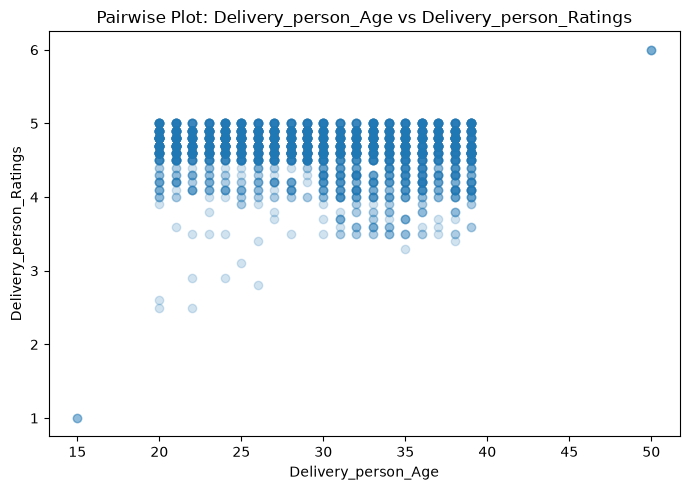

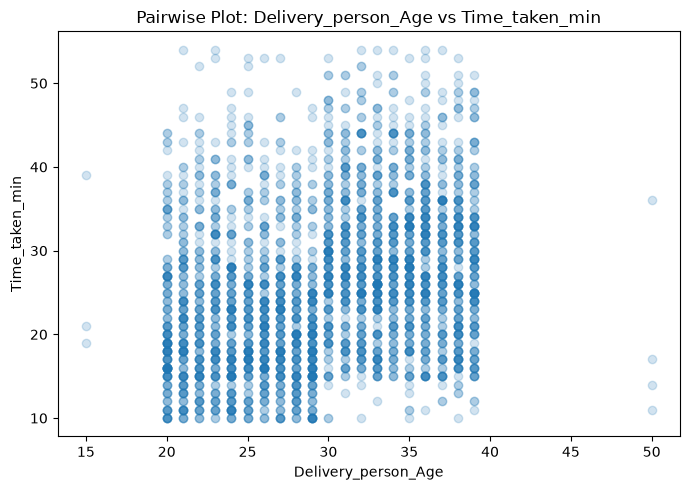

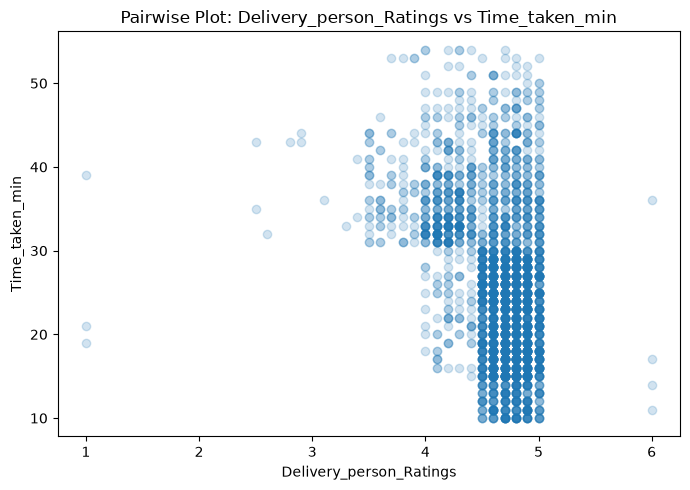

In [24]:
pairwise_columns = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Time_taken_min",
]

pairwise_sample = (
    df[pairwise_columns]
    .dropna()
    .sample(n=min(3000, len(df[pairwise_columns].dropna())), random_state=42)
)

pairs = [
    ("Delivery_person_Age", "Delivery_person_Ratings"),
    ("Delivery_person_Age", "Time_taken_min"),
    ("Delivery_person_Ratings", "Time_taken_min"),
]

for x_column, y_column in pairs:
    plt.figure(figsize=(7, 5))
    plt.scatter(
        pairwise_sample[x_column],
        pairwise_sample[y_column],
        alpha=0.2,
    )
    plt.title(f"Pairwise Plot: {x_column} vs {y_column}")
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.tight_layout()
    plt.show()

# 7. Index and Time Analysis

In [25]:
print(f"Default index unique: {df.index.is_unique}")
print(f"Default index sorted: {df.index.is_monotonic_increasing}")
print(f"ID unique: {df['ID'].is_unique}")
print(f"Order_Date is time-based: {pd.api.types.is_datetime64_any_dtype(df['Order_Date_parsed'])}")
print(f"Rows sorted chronologically by Order_Date: {df['Order_Date_parsed'].is_monotonic_increasing}")
print(f"Date range: {df['Order_Date_parsed'].min().date()} to {df['Order_Date_parsed'].max().date()}")
print(f"Unique order dates: {df['Order_Date_parsed'].nunique()}")

daily_delivery = (
    df.groupby("Order_Date_parsed", observed=True)["Time_taken_min"]
    .agg(["mean", "median", "count"])
    .sort_index()
)

display(daily_delivery.head())

Default index unique: True
Default index sorted: True
ID unique: True
Order_Date is time-based: True
Rows sorted chronologically by Order_Date: False
Date range: 2022-02-11 to 2022-04-06
Unique order dates: 44


,mean,median,count
Order_Date_parsed,,,
2022-02-11,23.421,23.000,970
2022-02-12,30.064,29.000,864
2022-02-13,23.356,23.000,957
2022-02-14,30.061,29.000,851
2022-02-15,23.294,23.000,945


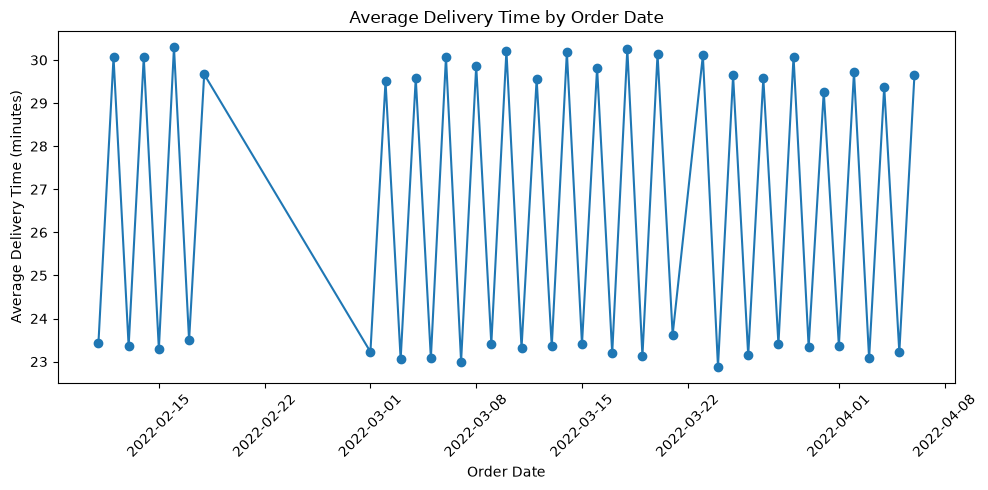

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(daily_delivery.index, daily_delivery["mean"], marker="o")
plt.title("Average Delivery Time by Order Date")
plt.xlabel("Order Date")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,mean,median,count
Day_of_week,,,
Monday,26.250,25.000,6207
Tuesday,25.320,25.000,6375
Wednesday,27.760,27.000,7093
Thursday,25.180,25.000,6348
Friday,26.820,26.000,7031
Saturday,26.100,25.500,6290
Sunday,26.400,25.000,6249


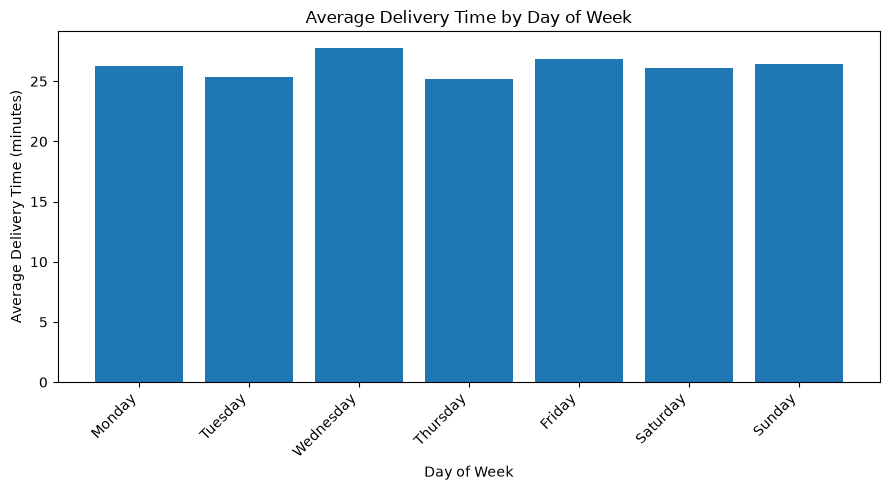

In [27]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_summary = (
    df.groupby("Day_of_week", observed=True)["Time_taken_min"]
    .agg(["mean", "median", "count"])
    .reindex(weekday_order)
)

display(weekday_summary.round(2))

plt.figure(figsize=(9, 5))
plt.bar(weekday_summary.index, weekday_summary["mean"])
plt.title("Average Delivery Time by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

,mean,median,count
Order_hour,,,
0.000,22.170,21.000,430
8.000,19.580,19.000,1818
9.000,19.540,19.000,1947
10.000,19.480,19.000,1991
11.000,26.380,27.000,1962
12.000,26.830,27.000,892
13.000,27.540,27.000,784
14.000,27.540,27.000,791
15.000,23.190,23.000,873


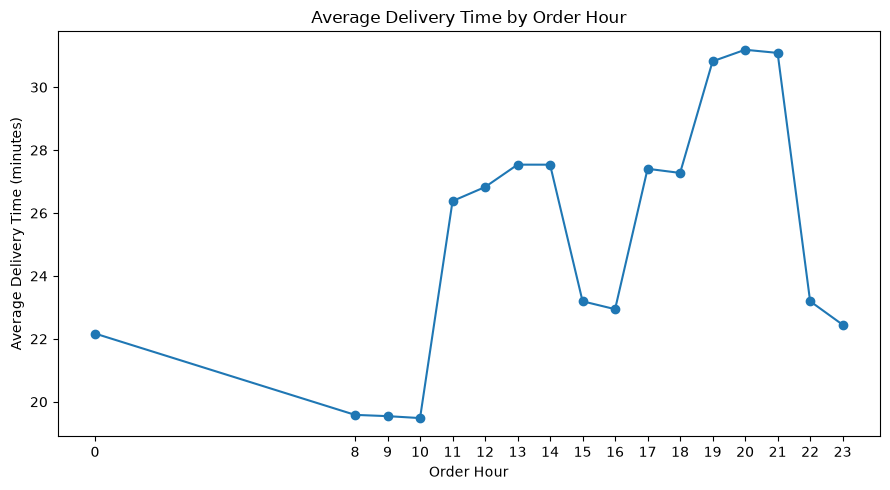

In [28]:
hour_summary = (
    df.groupby("Order_hour", observed=True)["Time_taken_min"]
    .agg(["mean", "median", "count"])
    .dropna()
)

display(hour_summary.round(2))

plt.figure(figsize=(9, 5))
plt.plot(hour_summary.index, hour_summary["mean"], marker="o")
plt.title("Average Delivery Time by Order Hour")
plt.xlabel("Order Hour")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(hour_summary.index)
plt.tight_layout()
plt.show()

### Index and time observation
The default row index is unique and sorted, but it is not time-based and carries no business meaning. `ID` is also unique and is a better order identifier.

The records themselves are **not sorted chronologically**. The date field spans 44 unique dates between February and April 2022. Average delivery time changes noticeably across dates, weekdays, and order hours, so time is relevant to the analysis.

However, the short time window limits generalization to other seasons or years. Any production model should be validated on later periods to check for temporal drift.

# 8. Insights and Data Story

## Main insights

### 1. Traffic is one of the clearest operational signals
Low-traffic orders average roughly 21 minutes, while jam-traffic orders average roughly 31 minutes. Traffic should therefore be treated as a major explanatory feature in delivery-time modeling and operational planning.

### 2. Courier-level variables contain useful signal
Courier rating is negatively associated with delivery time, while courier age and number of simultaneous deliveries are positively associated with time. These relationships may reflect experience, workload, route familiarity, vehicle choice, or other confounding variables; they should not be interpreted as direct causal effects.

### 3. Data quality can completely change a conclusion
Weather and traffic appear strongly related if the text `"NaN"` is accidentally treated as a real category. Once missing markers are correctly converted to missing values, Cramér's V falls to roughly 0.01. This demonstrates why data cleaning must occur before drawing conclusions from correlations.

## Bias / risk
The dataset covers a limited date range and appears operational rather than experimentally sampled. It may overrepresent certain cities, traffic regimes, couriers, or successfully completed deliveries. Missingness is also structured rather than purely random.

## Possible engineering and statistical failure points
- treating malformed coordinates as valid can create delivery distances of thousands of kilometers;
- using order IDs as predictive categories can cause overfitting;
- random train/test splitting can leak temporal patterns if the final use case is future prediction;
- imputing all missing weather/traffic values with the mode can hide a meaningful data-ingestion pattern;
- correlation between rating and delivery time does not establish causation.

## What this analysis changed
At first glance, the dataset looks clean because it has many rows and mostly reasonable operational fields. A deeper EDA reveals that the most important problems are subtle: textual missing markers, formatted numeric fields, coordinated missingness, implausible coordinates, and high-cardinality identifiers. The main lesson is that the measurement process must be understood before the numbers are trusted.

# 9. Bonus Analysis
## 9.1 Feature Engineering

In [29]:
# Keep the raw calculated distance, but treat extreme values as operationally implausible.
# The 100 km threshold is an explicit analysis assumption, not a source-dataset fact.
df["Distance_km_clean"] = df["Distance_km_raw"].where(df["Distance_km_raw"] <= 100)

engineered_feature_summary = pd.DataFrame(
    {
        "Feature": [
            "Preparation_time_min",
            "Order_hour",
            "Day_of_week",
            "Distance_km_clean",
        ],
        "Non-missing values": [
            df["Preparation_time_min"].notna().sum(),
            df["Order_hour"].notna().sum(),
            df["Day_of_week"].notna().sum(),
            df["Distance_km_clean"].notna().sum(),
        ],
    }
)

display(engineered_feature_summary)

print(
    "Distances removed by the >100 km sanity rule:",
    int(df["Distance_km_clean"].isna().sum() - df["Distance_km_raw"].isna().sum()),
)

,Feature,Non-missing values
0,Preparation_time_min,43862
1,Order_hour,43862
2,Day_of_week,45593
3,Distance_km_clean,45162


Distances removed by the >100 km sanity rule: 431


### Feature-engineering observation
The engineered features convert raw timestamps and coordinates into variables that are easier to interpret operationally. The distance feature also demonstrates why feature engineering must include validation: a mathematically correct Haversine formula still produces nonsense when the source coordinates are wrong.

## 9.2 Hypothesis Test — Does Delivery Time Differ by Traffic Level?

Because delivery time is not perfectly normal and group sizes are large, a **Kruskal–Wallis** test is used as a robust non-parametric comparison across the traffic categories.

- **H0:** the delivery-time distributions are the same across traffic levels.
- **H1:** at least one traffic level has a different delivery-time distribution.

In [30]:
traffic_groups = [
    group["Time_taken_min"].dropna().values
    for _, group in df.dropna(subset=["Road_traffic_density"]).groupby(
        "Road_traffic_density", observed=True
    )
]

kruskal_result = stats.kruskal(*traffic_groups)

print(f"Kruskal-Wallis H statistic: {kruskal_result.statistic:.3f}")
print(f"p-value: {kruskal_result.pvalue:.6g}")

Kruskal-Wallis H statistic: 8266.308
p-value: 0


### Hypothesis-test conclusion
The p-value is effectively zero at ordinary reporting precision, so the data provides very strong evidence that delivery-time distributions differ across road-traffic levels.

Statistical significance alone does not describe practical importance, so the earlier group means, binned percentages, boxplot, and violin plot are necessary to interpret the size and direction of the difference.

## 9.3 Suggestions for Further Research

1. Validate the analysis on a later time period to test temporal generalization.
2. Investigate the source of coordinated missing weather and traffic values.
3. Repair or exclude malformed coordinates before using route distance.
4. Model delivery time with interactions between traffic, city, vehicle type, multiple deliveries, and festival status.
5. Use a time-based validation split rather than only a random split for future prediction.
6. If available, add external variables such as precipitation intensity, road incidents, holidays, restaurant preparation load, and route-network distance.

# 10. Assignment Coverage Checklist

This notebook includes:
- dataset selection and source discussion,
- file size, format, dimensions, and creation-date limitation,
- column names, data types, and index analysis,
- missing-data amount, pattern, interpretation, and treatment,
- full and partial duplicate checks,
- suspicious values and placeholders,
- cardinality analysis,
- numerical statistics: mean, median, standard deviation, MAD, min/max, quantiles, IQR, skewness,
- three one-dimensional outlier methods,
- categorical frequencies, mode, Top-K coverage, P% coverage, and rarity discussion,
- Pearson, Spearman, and Kendall correlations with explanation,
- correlation matrix and heatmap,
- categorical–categorical contingency table and Cramér's V,
- categorical–numerical analysis with binning,
- scatter plots, histogram, bar chart, boxplot, violin plot, pie chart, pairwise plots, and heatmaps,
- time/index analysis,
- at least three central insights, bias/risk, and engineering/statistical failure points,
- bonus feature engineering, time dependence, hypothesis testing, and further-research suggestions.